<a href="https://colab.research.google.com/github/fmdsocial/pdj/blob/main/Review%20Prediction%20of%20mortality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Installation of packages**

In [ ]:
pip install statsmodels

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

# Load Excel data
# Replace 'path_to_your_file.xlsx' with the actual file path
# And adjust 'Sheet1' if your spreadsheet has a different name
data = pd.read_excel('/content/drive/MyDrive/Post-doc UFPel/Machine Learning Review & mortality - PDJ/PDJ Review/Meta-analysis/Meta.xlsx')

# Extracting columns
aucs = data['AUC'].to_numpy()
ses = data['SE'].to_numpy()

# Calculating inverse variance weights (for fixed effects)
weights_fixed = 1 / ses**2

# Calculating weighted mean of AUCs (Fixed Effects Model)
weighted_mean_auc_fixed = np.sum(aucs * weights_fixed) / np.sum(weights_fixed)

# Calculating heterogeneity
q_total = np.sum(weights_fixed * (aucs - weighted_mean_auc_fixed)**2)
df_q = len(aucs) - 1
p_value = 1 - norm.cdf(q_total, df_q)  # P-value for Q

# Calculating I²
i_squared = max(0, (q_total - df_q) / q_total * 100)  # In percentage

# Calculating tau² (between-study variance) using DerSimonian-Laird method
c = np.sum(weights_fixed) - (np.sum(weights_fixed**2) / np.sum(weights_fixed))
tau_squared = max(0, (q_total - df_q) / c)

# Calculating weights for random effects model
weights_random = 1 / (ses**2 + tau_squared)

# Calculating weighted mean of AUCs (Random Effects Model)
weighted_mean_auc_random = np.sum(aucs * weights_random) / np.sum(weights_random)

# Standard error for the combined random effects estimate
se_random = np.sqrt(1 / np.sum(weights_random))

# Calculating confidence intervals for random effects model
auc_random_ci_lower = weighted_mean_auc_random - 1.96 * se_random
auc_random_ci_upper = weighted_mean_auc_random + 1.96 * se_random

# Calculating confidence intervals for each study
ci_upper = aucs + 1.96 * ses
ci_lower = aucs - 1.96 * ses

# Creating forest plot
fig, ax = plt.subplots(figsize=(10, 8))  # Increasing size for better visualization

# Plotting confidence intervals for individual studies
# Point size proportional to relative weights
max_weight = np.max(weights_random)
point_sizes = 30 * (weights_random / max_weight)

for i in range(len(aucs)):
    ax.plot([ci_lower[i], ci_upper[i]], [i, i], 'b-', alpha=0.6)
    ax.plot(aucs[i], i, 'bo', ms=np.sqrt(point_sizes[i]), alpha=0.8)

# Adding combined estimate from random effects model
# Using a diamond to represent the combined estimate
diamond_height = 0.4
y_diamond = len(aucs)
diamond_xs = [auc_random_ci_lower, weighted_mean_auc_random, auc_random_ci_upper, weighted_mean_auc_random, auc_random_ci_lower]
diamond_ys = [y_diamond, y_diamond + diamond_height, y_diamond, y_diamond - diamond_height, y_diamond]
ax.fill(diamond_xs, diamond_ys, color='red', alpha=0.6)

# Adding vertical line for combined estimate
ax.axvline(weighted_mean_auc_random, color='red', linestyle='dotted', alpha=0.6)

# Adding plot details
ax.set_yticks(range(len(aucs) + 1))
# Removing study labels
ax.set_yticklabels([''] * len(aucs) + [''])
ax.invert_yaxis()  # Invert to have study 1 at the top

# Removing display of AUC values and CIs on the right side of the plot (removing entire section)
# Setting x-axis limits and adding grid
ax.set_xlim(0.5, 1.0)  # Returning to original limit without text on the right
ax.grid(True, axis='x', linestyle='--', alpha=0.3)
ax.set_xlabel('AUC (Area Under the ROC Curve)', fontsize=12)
ax.set_title('Forest Plot - Meta-Analysis with Random-Effects Model', fontsize=14)

# Adding text box with meta-analysis results
result_text = (
    f'Random-Effects Model Results:\n'
    f'AUC = {weighted_mean_auc_random:.3f} (95% CI: [{auc_random_ci_lower:.3f}, {auc_random_ci_upper:.3f}])\n\n'
    f'Heterogeneity:\n'
    f'I² = {i_squared:.1f}%'
)
plt.figtext(0.15, 0.01, result_text, bbox=dict(boxstyle="round,pad=0.5",
                                              facecolor='lightyellow',
                                              alpha=0.5),
            horizontalalignment='left')

# Adjusting layout
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)  # Adjusting to make space for the box below

plt.show()

# Printing results to console for reference
print(f"Fixed-Effects Model:")
print(f"AUC = {weighted_mean_auc_fixed:.4f} (95% CI: [{weighted_mean_auc_fixed - 1.96 * np.sqrt(1 / np.sum(weights_fixed)):.4f}, {weighted_mean_auc_fixed + 1.96 * np.sqrt(1 / np.sum(weights_fixed)):.4f}])")
print("\nRandom-Effects Model:")
print(f"AUC = {weighted_mean_auc_random:.4f} (95% CI: [{auc_random_ci_lower:.4f}, {auc_random_ci_upper:.4f}])")
print(f"I² = {i_squared:.1f}%")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# Load Excel data
data = pd.read_excel('/content/drive/MyDrive/Post-doc UFPel/Machine Learning Review & mortality - PDJ/PDJ Review/Meta-analysis/Meta.xlsx')

# Extracting columns
aucs = data['AUC'].to_numpy()
ses = data['SE'].to_numpy()

# Calculating inverse variance weights (for fixed effects)
weights_fixed = 1 / ses**2

# Calculating weighted mean of AUCs (Fixed Effects Model)
weighted_mean_auc_fixed = np.sum(aucs * weights_fixed) / np.sum(weights_fixed)

# Calculating heterogeneity
q_total = np.sum(weights_fixed * (aucs - weighted_mean_auc_fixed)**2)
df_q = len(aucs) - 1

# Calculating I²
i_squared = max(0, (q_total - df_q) / q_total * 100) if q_total > 0 else 0  # In percentage

# Calculating tau² (between-study variance) using DerSimonian-Laird method
c = np.sum(weights_fixed) - (np.sum(weights_fixed**2) / np.sum(weights_fixed))
tau_squared = max(0, (q_total - df_q) / c)

# Calculating weights for random effects model
weights_random = 1 / (ses**2 + tau_squared)

# Calculating weighted mean of AUCs (Random Effects Model)
weighted_mean_auc_random = np.sum(aucs * weights_random) / np.sum(weights_random)

# Standard error for the combined random effects estimate
se_random = np.sqrt(1 / np.sum(weights_random))

# Calculating confidence intervals for random effects model
random_ci_lower = weighted_mean_auc_random - 1.96 * se_random
random_ci_upper = weighted_mean_auc_random + 1.96 * se_random

# Calculating confidence intervals for each study
ci_upper = np.minimum(aucs + 1.96 * ses, 1)  # Limiting upper CI to 1
ci_lower = np.maximum(aucs - 1.96 * ses, 0)  # Limiting lower CI to 0

# Creating data for violin plot
simulated_data = []
categories = []
for i, (auc, lower, upper) in enumerate(zip(aucs, ci_lower, ci_upper)):
    # Simulating distribution for each study based on AUC and its confidence intervals
    simulated_auc = np.random.normal(loc=auc, scale=(upper - lower) / 4, size=200)
    simulated_data.extend(simulated_auc)
    categories.extend([f'{i+1}' for _ in range(len(simulated_auc))])

# Simulating data for the random effects weighted mean
simulated_mean_data = np.random.normal(
    loc=weighted_mean_auc_random,
    scale=(random_ci_upper - random_ci_lower) / 4,
    size=200
)
simulated_data.extend(simulated_mean_data)
categories.extend(['Overall'] * len(simulated_mean_data))

# Creating violin plot
fig, ax = plt.subplots(figsize=(14, 8))
sns.violinplot(x=categories, y=simulated_data, cut=0, scale='width', inner=None, linewidth=1.5)
ax.set_ylabel('AUC Value')
ax.set_xlabel('Study Index')
ax.set_title('Violin Plot of AUC Distribution per Study with Random-Effects Model')

# Plotting mean points as reference
for i, (auc, lower, upper) in enumerate(zip(aucs, ci_lower, ci_upper)):
    ax.scatter(i, auc, color='red', s=50, zorder=3)
    ax.plot([i, i], [lower, upper], color='red', lw=2, zorder=2)

# Adding the random effects meta-analysis result
ax.scatter(len(aucs), weighted_mean_auc_random, color='green', s=100, zorder=3)
ax.plot([len(aucs), len(aucs)], [random_ci_lower, random_ci_upper], color='green', lw=3, zorder=2)
ax.axhline(y=weighted_mean_auc_random, color='green', linestyle='--', linewidth=2, label='Overall Mean AUC (RE)')  # Dashed line

# Adding text box with random effects model result
result_text = (
    f'Random-Effects Model Results:\n'
    f'AUC = {weighted_mean_auc_random:.3f}\n'
    f'95% CI: [{random_ci_lower:.3f}, {random_ci_upper:.3f}]\n'
    f'Heterogeneity: I² = {i_squared:.1f}%'
)
ax.text(0.5, 0.1, result_text, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', edgecolor='black'))

# Setting X-axis labels
ax.set_xticklabels([''] * len(aucs) + ['Overall'])
plt.xticks(rotation=90)

# Limiting Y-axis to maximum 1
ax.set_ylim(0.4, 1)

plt.legend()
plt.tight_layout()
plt.show()

# Printing results to console for reference
print(f"Fixed-Effects Model:")
print(f"AUC = {weighted_mean_auc_fixed:.4f} (95% CI: [{weighted_mean_auc_fixed - 1.96 * np.sqrt(1 / np.sum(weights_fixed)):.4f}, {weighted_mean_auc_fixed + 1.96 * np.sqrt(1 / np.sum(weights_fixed)):.4f}])")
print("\nRandom-Effects Model:")
print(f"AUC = {weighted_mean_auc_random:.4f} (95% CI: [{random_ci_lower:.4f}, {random_ci_upper:.4f}])")
print(f"I² = {i_squared:.1f}%")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

# Load Excel data
# Replace 'path_to_your_file.xlsx' with the actual file path
# And adjust 'Sheet1' if your spreadsheet has a different name
data = pd.read_excel('/content/drive/MyDrive/Post-doc UFPel/Machine Learning Review & mortality - PDJ/PDJ Review/Meta-analysis/Metasaudavel.xlsx')

# Extracting columns
aucs = data['AUC'].to_numpy()
ses = data['SE'].to_numpy()

# Calculating inverse variance weights (for fixed effects)
weights_fixed = 1 / ses**2

# Calculating weighted mean of AUCs (Fixed Effects Model)
weighted_mean_auc_fixed = np.sum(aucs * weights_fixed) / np.sum(weights_fixed)

# Calculating heterogeneity
q_total = np.sum(weights_fixed * (aucs - weighted_mean_auc_fixed)**2)
df_q = len(aucs) - 1
p_value = 1 - norm.cdf(q_total, df_q)  # P-value for Q

# Calculating I²
i_squared = max(0, (q_total - df_q) / q_total * 100)  # In percentage

# Calculating tau² (between-study variance) using DerSimonian-Laird method
c = np.sum(weights_fixed) - (np.sum(weights_fixed**2) / np.sum(weights_fixed))
tau_squared = max(0, (q_total - df_q) / c)

# Calculating weights for random effects model
weights_random = 1 / (ses**2 + tau_squared)

# Calculating weighted mean of AUCs (Random Effects Model)
weighted_mean_auc_random = np.sum(aucs * weights_random) / np.sum(weights_random)

# Standard error for the combined random effects estimate
se_random = np.sqrt(1 / np.sum(weights_random))

# Calculating confidence intervals for random effects model
auc_random_ci_lower = weighted_mean_auc_random - 1.96 * se_random
auc_random_ci_upper = weighted_mean_auc_random + 1.96 * se_random

# Calculating confidence intervals for each study
ci_upper = aucs + 1.96 * ses
ci_lower = aucs - 1.96 * ses

# Creating forest plot
fig, ax = plt.subplots(figsize=(10, 8))  # Increasing size for better visualization

# Plotting confidence intervals for individual studies
# Point size proportional to relative weights
max_weight = np.max(weights_random)
point_sizes = 30 * (weights_random / max_weight)

for i in range(len(aucs)):
    ax.plot([ci_lower[i], ci_upper[i]], [i, i], 'b-', alpha=0.6)
    ax.plot(aucs[i], i, 'bo', ms=np.sqrt(point_sizes[i]), alpha=0.8)

# Adding combined estimate from random effects model
# Using a diamond to represent the combined estimate
diamond_height = 0.4
y_diamond = len(aucs)
diamond_xs = [auc_random_ci_lower, weighted_mean_auc_random, auc_random_ci_upper, weighted_mean_auc_random, auc_random_ci_lower]
diamond_ys = [y_diamond, y_diamond + diamond_height, y_diamond, y_diamond - diamond_height, y_diamond]
ax.fill(diamond_xs, diamond_ys, color='red', alpha=0.6)

# Adding vertical line for combined estimate
ax.axvline(weighted_mean_auc_random, color='red', linestyle='dotted', alpha=0.6)

# Adding plot details
ax.set_yticks(range(len(aucs) + 1))
# Removing study labels
ax.set_yticklabels([''] * len(aucs) + [''])
ax.invert_yaxis()  # Invert to have study 1 at the top

# Removing display of AUC values and CIs on the right side of the plot (removing entire section)
# Setting x-axis limits and adding grid
ax.set_xlim(0.5, 1.0)  # Returning to original limit without text on the right
ax.grid(True, axis='x', linestyle='--', alpha=0.3)
ax.set_xlabel('AUC (Area Under the ROC Curve)', fontsize=12)
ax.set_title('Forest Plot for meta-analysis between studies with general population', fontsize=14)

# Adding text box with meta-analysis results
result_text = (
    f'Random-Effects Model Results:\n'
    f'AUC = {weighted_mean_auc_random:.3f} (95% CI: [{auc_random_ci_lower:.3f}, {auc_random_ci_upper:.3f}])\n\n'
    f'Heterogeneity:\n'
    f'I² = {i_squared:.1f}%'
)
plt.figtext(0.15, 0.01, result_text, bbox=dict(boxstyle="round,pad=0.5",
                                              facecolor='lightyellow',
                                              alpha=0.5),
            horizontalalignment='left')

# Adjusting layout
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)  # Adjusting to make space for the box below

plt.show()

# Printing results to console for reference
print(f"Fixed-Effects Model:")
print(f"AUC = {weighted_mean_auc_fixed:.4f} (95% CI: [{weighted_mean_auc_fixed - 1.96 * np.sqrt(1 / np.sum(weights_fixed)):.4f}, {weighted_mean_auc_fixed + 1.96 * np.sqrt(1 / np.sum(weights_fixed)):.4f}])")
print("\nRandom-Effects Model:")
print(f"AUC = {weighted_mean_auc_random:.4f} (95% CI: [{auc_random_ci_lower:.4f}, {auc_random_ci_upper:.4f}])")
print(f"I² = {i_squared:.1f}%")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# Load Excel data
data = pd.read_excel('/content/drive/MyDrive/Post-doc UFPel/Machine Learning Review & mortality - PDJ/PDJ Review/Meta-analysis/Metasaudavel.xlsx')

# Extracting columns
aucs = data['AUC'].to_numpy()
ses = data['SE'].to_numpy()

# Calculating inverse variance weights (for fixed effects)
weights_fixed = 1 / ses**2

# Calculating weighted mean of AUCs (Fixed Effects Model)
weighted_mean_auc_fixed = np.sum(aucs * weights_fixed) / np.sum(weights_fixed)

# Calculating heterogeneity
q_total = np.sum(weights_fixed * (aucs - weighted_mean_auc_fixed)**2)
df_q = len(aucs) - 1

# Calculating I²
i_squared = max(0, (q_total - df_q) / q_total * 100) if q_total > 0 else 0  # In percentage

# Calculating tau² (between-study variance) using DerSimonian-Laird method
c = np.sum(weights_fixed) - (np.sum(weights_fixed**2) / np.sum(weights_fixed))
tau_squared = max(0, (q_total - df_q) / c)

# Calculating weights for random effects model
weights_random = 1 / (ses**2 + tau_squared)

# Calculating weighted mean of AUCs (Random Effects Model)
weighted_mean_auc_random = np.sum(aucs * weights_random) / np.sum(weights_random)

# Standard error for the combined random effects estimate
se_random = np.sqrt(1 / np.sum(weights_random))

# Calculating confidence intervals for random effects model
random_ci_lower = weighted_mean_auc_random - 1.96 * se_random
random_ci_upper = weighted_mean_auc_random + 1.96 * se_random

# Calculating confidence intervals for each study
ci_upper = np.minimum(aucs + 1.96 * ses, 1)  # Limiting upper CI to 1
ci_lower = np.maximum(aucs - 1.96 * ses, 0)  # Limiting lower CI to 0

# Creating data for violin plot
simulated_data = []
categories = []
for i, (auc, lower, upper) in enumerate(zip(aucs, ci_lower, ci_upper)):
    # Simulating distribution for each study based on AUC and its confidence intervals
    simulated_auc = np.random.normal(loc=auc, scale=(upper - lower) / 4, size=200)
    simulated_data.extend(simulated_auc)
    categories.extend([f'{i+1}' for _ in range(len(simulated_auc))])

# Simulating data for the random effects weighted mean
simulated_mean_data = np.random.normal(
    loc=weighted_mean_auc_random,
    scale=(random_ci_upper - random_ci_lower) / 4,
    size=200
)
simulated_data.extend(simulated_mean_data)
categories.extend(['Overall'] * len(simulated_mean_data))

# Creating violin plot
fig, ax = plt.subplots(figsize=(14, 8))
sns.violinplot(x=categories, y=simulated_data, cut=0, scale='width', inner=None, linewidth=1.5)
ax.set_ylabel('AUC Value')
ax.set_xlabel('Study Index')
ax.set_title('Violin Plot of AUC Distribution per Study with Overall Meta-Analysis Result between studies with general population')

# Plotting mean points as reference
for i, (auc, lower, upper) in enumerate(zip(aucs, ci_lower, ci_upper)):
    ax.scatter(i, auc, color='red', s=50, zorder=3)
    ax.plot([i, i], [lower, upper], color='red', lw=2, zorder=2)

# Adding the random effects meta-analysis result
ax.scatter(len(aucs), weighted_mean_auc_random, color='green', s=100, zorder=3)
ax.plot([len(aucs), len(aucs)], [random_ci_lower, random_ci_upper], color='green', lw=3, zorder=2)
ax.axhline(y=weighted_mean_auc_random, color='green', linestyle='--', linewidth=2, label='Overall Mean AUC (RE)')  # Dashed line

# Adding text box with random effects model result
result_text = (
    f'Random-Effects Model Results:\n'
    f'AUC = {weighted_mean_auc_random:.3f}\n'
    f'95% CI: [{random_ci_lower:.3f}, {random_ci_upper:.3f}]\n'
    f'Heterogeneity: I² = {i_squared:.1f}%'
)
ax.text(0.5, 0.1, result_text, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', edgecolor='black'))

# Setting X-axis labels
ax.set_xticklabels([''] * len(aucs) + ['Overall'])
plt.xticks(rotation=90)

# Limiting Y-axis to maximum 1
ax.set_ylim(0.4, 1)

plt.legend()
plt.tight_layout()
plt.show()

# Printing results to console for reference
print(f"Fixed-Effects Model:")
print(f"AUC = {weighted_mean_auc_fixed:.4f} (95% CI: [{weighted_mean_auc_fixed - 1.96 * np.sqrt(1 / np.sum(weights_fixed)):.4f}, {weighted_mean_auc_fixed + 1.96 * np.sqrt(1 / np.sum(weights_fixed)):.4f}])")
print("\nRandom-Effects Model:")
print(f"AUC = {weighted_mean_auc_random:.4f} (95% CI: [{random_ci_lower:.4f}, {random_ci_upper:.4f}])")
print(f"I² = {i_squared:.1f}%")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

# Load Excel data
# Replace 'path_to_your_file.xlsx' with the actual file path
# And adjust 'Sheet1' if your spreadsheet has a different name
data = pd.read_excel('/content/drive/MyDrive/Post-doc UFPel/Machine Learning Review & mortality - PDJ/PDJ Review/Meta-analysis/Metadoente.xlsx')

# Extracting columns
aucs = data['AUC'].to_numpy()
ses = data['SE'].to_numpy()

# Calculating inverse variance weights (for fixed effects)
weights_fixed = 1 / ses**2

# Calculating weighted mean of AUCs (Fixed Effects Model)
weighted_mean_auc_fixed = np.sum(aucs * weights_fixed) / np.sum(weights_fixed)

# Calculating heterogeneity
q_total = np.sum(weights_fixed * (aucs - weighted_mean_auc_fixed)**2)
df_q = len(aucs) - 1
p_value = 1 - norm.cdf(q_total, df_q)  # P-value for Q

# Calculating I²
i_squared = max(0, (q_total - df_q) / q_total * 100)  # In percentage

# Calculating tau² (between-study variance) using DerSimonian-Laird method
c = np.sum(weights_fixed) - (np.sum(weights_fixed**2) / np.sum(weights_fixed))
tau_squared = max(0, (q_total - df_q) / c)

# Calculating weights for random effects model
weights_random = 1 / (ses**2 + tau_squared)

# Calculating weighted mean of AUCs (Random Effects Model)
weighted_mean_auc_random = np.sum(aucs * weights_random) / np.sum(weights_random)

# Standard error for the combined random effects estimate
se_random = np.sqrt(1 / np.sum(weights_random))

# Calculating confidence intervals for random effects model
auc_random_ci_lower = weighted_mean_auc_random - 1.96 * se_random
auc_random_ci_upper = weighted_mean_auc_random + 1.96 * se_random

# Calculating confidence intervals for each study
ci_upper = aucs + 1.96 * ses
ci_lower = aucs - 1.96 * ses

# Creating forest plot
fig, ax = plt.subplots(figsize=(10, 8))  # Increasing size for better visualization

# Plotting confidence intervals for individual studies
# Point size proportional to relative weights
max_weight = np.max(weights_random)
point_sizes = 30 * (weights_random / max_weight)

for i in range(len(aucs)):
    ax.plot([ci_lower[i], ci_upper[i]], [i, i], 'b-', alpha=0.6)
    ax.plot(aucs[i], i, 'bo', ms=np.sqrt(point_sizes[i]), alpha=0.8)

# Adding combined estimate from random effects model
# Using a diamond to represent the combined estimate
diamond_height = 0.4
y_diamond = len(aucs)
diamond_xs = [auc_random_ci_lower, weighted_mean_auc_random, auc_random_ci_upper, weighted_mean_auc_random, auc_random_ci_lower]
diamond_ys = [y_diamond, y_diamond + diamond_height, y_diamond, y_diamond - diamond_height, y_diamond]
ax.fill(diamond_xs, diamond_ys, color='red', alpha=0.6)

# Adding vertical line for combined estimate
ax.axvline(weighted_mean_auc_random, color='red', linestyle='dotted', alpha=0.6)

# Adding plot details
ax.set_yticks(range(len(aucs) + 1))
# Removing study labels
ax.set_yticklabels([''] * len(aucs) + [''])
ax.invert_yaxis()  # Invert to have study 1 at the top

# Removing display of AUC values and CIs on the right side of the plot (removing entire section)
# Setting x-axis limits and adding grid
ax.set_xlim(0.5, 1.0)  # Returning to original limit without text on the right
ax.grid(True, axis='x', linestyle='--', alpha=0.3)
ax.set_xlabel('AUC (Area Under the ROC Curve)', fontsize=12)
ax.set_title('Forest Plot for meta-analysis between studies with people with diseases or some other health condition', fontsize=14)

# Adding text box with meta-analysis results
result_text = (
    f'Random-Effects Model Results:\n'
    f'AUC = {weighted_mean_auc_random:.3f} (95% CI: [{auc_random_ci_lower:.3f}, {auc_random_ci_upper:.3f}])\n\n'
    f'Heterogeneity:\n'
    f'I² = {i_squared:.1f}%'
)
plt.figtext(0.15, 0.01, result_text, bbox=dict(boxstyle="round,pad=0.5",
                                              facecolor='lightyellow',
                                              alpha=0.5),
            horizontalalignment='left')

# Adjusting layout
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)  # Adjusting to make space for the box below

plt.show()

# Printing results to console for reference
print(f"Fixed-Effects Model:")
print(f"AUC = {weighted_mean_auc_fixed:.4f} (95% CI: [{weighted_mean_auc_fixed - 1.96 * np.sqrt(1 / np.sum(weights_fixed)):.4f}, {weighted_mean_auc_fixed + 1.96 * np.sqrt(1 / np.sum(weights_fixed)):.4f}])")
print("\nRandom-Effects Model:")
print(f"AUC = {weighted_mean_auc_random:.4f} (95% CI: [{auc_random_ci_lower:.4f}, {auc_random_ci_upper:.4f}])")
print(f"I² = {i_squared:.1f}%")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# Load Excel data
data = pd.read_excel('/content/drive/MyDrive/Post-doc UFPel/Machine Learning Review & mortality - PDJ/PDJ Review/Meta-analysis/Metadoente.xlsx')

# Extracting columns
aucs = data['AUC'].to_numpy()
ses = data['SE'].to_numpy()

# Calculating inverse variance weights (for fixed effects)
weights_fixed = 1 / ses**2

# Calculating weighted mean of AUCs (Fixed Effects Model)
weighted_mean_auc_fixed = np.sum(aucs * weights_fixed) / np.sum(weights_fixed)

# Calculating heterogeneity
q_total = np.sum(weights_fixed * (aucs - weighted_mean_auc_fixed)**2)
df_q = len(aucs) - 1

# Calculating I²
i_squared = max(0, (q_total - df_q) / q_total * 100) if q_total > 0 else 0  # In percentage

# Calculating tau² (between-study variance) using DerSimonian-Laird method
c = np.sum(weights_fixed) - (np.sum(weights_fixed**2) / np.sum(weights_fixed))
tau_squared = max(0, (q_total - df_q) / c)

# Calculating weights for random effects model
weights_random = 1 / (ses**2 + tau_squared)

# Calculating weighted mean of AUCs (Random Effects Model)
weighted_mean_auc_random = np.sum(aucs * weights_random) / np.sum(weights_random)

# Standard error for the combined random effects estimate
se_random = np.sqrt(1 / np.sum(weights_random))

# Calculating confidence intervals for random effects model
random_ci_lower = weighted_mean_auc_random - 1.96 * se_random
random_ci_upper = weighted_mean_auc_random + 1.96 * se_random

# Calculating confidence intervals for each study
ci_upper = np.minimum(aucs + 1.96 * ses, 1)  # Limiting upper CI to 1
ci_lower = np.maximum(aucs - 1.96 * ses, 0)  # Limiting lower CI to 0

# Creating data for violin plot
simulated_data = []
categories = []
for i, (auc, lower, upper) in enumerate(zip(aucs, ci_lower, ci_upper)):
    # Simulating distribution for each study based on AUC and its confidence intervals
    simulated_auc = np.random.normal(loc=auc, scale=(upper - lower) / 4, size=200)
    simulated_data.extend(simulated_auc)
    categories.extend([f'{i+1}' for _ in range(len(simulated_auc))])

# Simulating data for the random effects weighted mean
simulated_mean_data = np.random.normal(
    loc=weighted_mean_auc_random,
    scale=(random_ci_upper - random_ci_lower) / 4,
    size=200
)
simulated_data.extend(simulated_mean_data)
categories.extend(['Overall'] * len(simulated_mean_data))

# Creating violin plot
fig, ax = plt.subplots(figsize=(14, 8))
sns.violinplot(x=categories, y=simulated_data, cut=0, scale='width', inner=None, linewidth=1.5)
ax.set_ylabel('AUC Value')
ax.set_xlabel('Study Index')
ax.set_title('Violin Plot of AUC Distribution per Study with Overall Meta-Analysis Result between studies with people with diseases or some other health condition')

# Plotting mean points as reference
for i, (auc, lower, upper) in enumerate(zip(aucs, ci_lower, ci_upper)):
    ax.scatter(i, auc, color='red', s=50, zorder=3)
    ax.plot([i, i], [lower, upper], color='red', lw=2, zorder=2)

# Adding the random effects meta-analysis result
ax.scatter(len(aucs), weighted_mean_auc_random, color='green', s=100, zorder=3)
ax.plot([len(aucs), len(aucs)], [random_ci_lower, random_ci_upper], color='green', lw=3, zorder=2)
ax.axhline(y=weighted_mean_auc_random, color='green', linestyle='--', linewidth=2, label='Overall Mean AUC (RE)')  # Dashed line

# Adding text box with random effects model result
result_text = (
    f'Random-Effects Model Results:\n'
    f'AUC = {weighted_mean_auc_random:.3f}\n'
    f'95% CI: [{random_ci_lower:.3f}, {random_ci_upper:.3f}]\n'
    f'Heterogeneity: I² = {i_squared:.1f}%'
)
ax.text(0.5, 0.1, result_text, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', edgecolor='black'))

# Setting X-axis labels
ax.set_xticklabels([''] * len(aucs) + ['Overall'])
plt.xticks(rotation=90)

# Limiting Y-axis to maximum 1
ax.set_ylim(0.4, 1)

plt.legend()
plt.tight_layout()
plt.show()

# Printing results to console for reference
print(f"Fixed-Effects Model:")
print(f"AUC = {weighted_mean_auc_fixed:.4f} (95% CI: [{weighted_mean_auc_fixed - 1.96 * np.sqrt(1 / np.sum(weights_fixed)):.4f}, {weighted_mean_auc_fixed + 1.96 * np.sqrt(1 / np.sum(weights_fixed)):.4f}])")
print("\nRandom-Effects Model:")
print(f"AUC = {weighted_mean_auc_random:.4f} (95% CI: [{random_ci_lower:.4f}, {random_ci_upper:.4f}])")
print(f"I² = {i_squared:.1f}%")

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import norm

# Load Excel data
data = pd.read_excel('/content/drive/MyDrive/Post-doc UFPel/Machine Learning Review & mortality - PDJ/PDJ Review/Meta-analysis/Metapais.xlsx')

# Function to calculate meta-analysis with random effects model
def random_effects_meta_analysis(aucs, ses):
    # Fixed effects model calculation (necessary to estimate heterogeneity)
    weights_fixed = 1 / ses**2
    weighted_mean_auc_fixed = np.sum(aucs * weights_fixed) / np.sum(weights_fixed)

    # Q statistic calculation (heterogeneity)
    q_total = np.sum(weights_fixed * (aucs - weighted_mean_auc_fixed)**2)
    df_q = len(aucs) - 1

    # I² calculation (percentage of variation due to heterogeneity)
    i_squared = max(0, (q_total - df_q) / q_total * 100) if q_total > 0 else 0

    # tau² calculation (between-study variance) using DerSimonian-Laird method
    c = np.sum(weights_fixed) - (np.sum(weights_fixed**2) / np.sum(weights_fixed))
    tau_squared = max(0, (q_total - df_q) / c)

    # Weights calculation for random effects model
    weights_random = 1 / (ses**2 + tau_squared)

    # Combined estimate calculation for random effects model
    weighted_mean_auc_random = np.sum(aucs * weights_random) / np.sum(weights_random)

    # Standard error for combined estimate
    se_random = np.sqrt(1 / np.sum(weights_random))

    # 95% confidence intervals for combined estimate
    ci_lower = weighted_mean_auc_random - 1.96 * se_random
    ci_upper = weighted_mean_auc_random + 1.96 * se_random

    return weighted_mean_auc_random, i_squared, tau_squared, ci_lower, ci_upper

# Subgroup analysis with random effects model
print("Subgroup Analysis with Random Effects Model\n")
print("-" * 60)

# List to store results of each subgroup for later analysis
subgroup_results = []

for classification in sorted(data['Classification'].unique()):
    subgroup_data = data[data['Classification'] == classification]
    aucs = subgroup_data['AUC'].to_numpy()
    ses = subgroup_data['SE'].to_numpy()

    if len(aucs) > 1:  # Check if there are enough studies for meta-analysis
        weighted_mean_auc, i_squared, tau_squared, ci_lower, ci_upper = random_effects_meta_analysis(aucs, ses)

        print(f"Subgroup {classification} (n = {len(aucs)} studies):")
        print(f"  AUC = {weighted_mean_auc:.3f} (95% CI: [{ci_lower:.3f}, {ci_upper:.3f}])")
        print(f"  Heterogeneity (I²): {i_squared:.1f}%")
        print(f"  Between-study variance (τ²): {tau_squared:.6f}")
        print()

        # Store results for later analysis
        subgroup_results.append({
            'classification': classification,
            'n_studies': len(aucs),
            'auc': weighted_mean_auc,
            'ci_lower': ci_lower,
            'ci_upper': ci_upper,
            'i_squared': i_squared,
            'tau_squared': tau_squared
        })
    else:
        print(f"Subgroup {classification} (n = {len(aucs)} studies):")
        print("  Insufficient number of studies for meta-analysis")
        print()

# Overall meta-analysis (all studies)
print("-" * 60)
print("Overall Analysis (All Studies):")
aucs_all = data['AUC'].to_numpy()
ses_all = data['SE'].to_numpy()

weighted_mean_auc, i_squared, tau_squared, ci_lower, ci_upper = random_effects_meta_analysis(aucs_all, ses_all)

print(f"  Total studies: {len(aucs_all)}")
print(f"  AUC = {weighted_mean_auc:.3f} (95% CI: [{ci_lower:.3f}, {ci_upper:.3f}])")
print(f"  Heterogeneity (I²): {i_squared:.1f}%")
print(f"  Between-study variance (τ²): {tau_squared:.6f}")
print("-" * 60)

# Analysis of differences between subgroups (if there are at least 2 subgroups)
if len(subgroup_results) >= 2:
    print("\nAnalysis of Differences Between Subgroups:")

    # Calculate Q statistic between subgroups
    q_between = 0
    for result in subgroup_results:
        weights = 1 / (result['ci_upper'] - result['ci_lower'])**2 * 4
        q_between += weights * (result['auc'] - weighted_mean_auc)**2

    df_between = len(subgroup_results) - 1
    p_value = 1 - norm.cdf(q_between, df_between)

    print(f"  Q statistic between subgroups: {q_between:.2f} (df = {df_between})")
    print(f"  P-value for difference between subgroups: {p_value:.4f}")

    if p_value < 0.05:
        print("  There is a statistically significant difference between subgroups (p < 0.05)")
    else:
        print("  There is no statistically significant difference between subgroups (p ≥ 0.05)")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load Excel data
data = pd.read_excel('/content/drive/MyDrive/Post-doc UFPel/Machine Learning Review & mortality - PDJ/PDJ Review/Meta-analysis/Metapais.xlsx')

# Function to calculate meta-analysis with random effects model
def random_effects_meta_analysis(aucs, ses):
    # Fixed effects model calculation (necessary to estimate heterogeneity)
    weights_fixed = 1 / ses**2
    weighted_mean_auc_fixed = np.sum(aucs * weights_fixed) / np.sum(weights_fixed)

    # Q statistic calculation (heterogeneity)
    q_total = np.sum(weights_fixed * (aucs - weighted_mean_auc_fixed)**2)
    df_q = len(aucs) - 1

    # I² calculation (percentage of variation due to heterogeneity)
    i_squared = max(0, (q_total - df_q) / q_total * 100) if q_total > 0 else 0

    # tau² calculation (between-study variance) using DerSimonian-Laird method
    c = np.sum(weights_fixed) - (np.sum(weights_fixed**2) / np.sum(weights_fixed))
    tau_squared = max(0, (q_total - df_q) / c)

    # Weights calculation for random effects model
    weights_random = 1 / (ses**2 + tau_squared)

    # Combined estimate calculation for random effects model
    weighted_mean_auc_random = np.sum(aucs * weights_random) / np.sum(weights_random)

    # Standard error for combined estimate
    se_random = np.sqrt(1 / np.sum(weights_random))

    # 95% confidence intervals for combined estimate
    ci_lower = weighted_mean_auc_random - 1.96 * se_random
    ci_upper = weighted_mean_auc_random + 1.96 * se_random

    return weighted_mean_auc_random, ci_lower, ci_upper, i_squared, tau_squared

# Calculating meta-analysis for each subgroup
results = {}
for classification in [1, 2]:
    subgroup_data = data[data['Classification'] == classification]
    aucs = subgroup_data['AUC'].to_numpy()
    ses = subgroup_data['SE'].to_numpy()

    results[classification] = random_effects_meta_analysis(aucs, ses)

# Creating single forest plot
fig, ax = plt.subplots(figsize=(10, 8))

colors = {1: 'blue', 2: 'red'}
labels = {1: 'High-income countries', 2: 'Low- and middle-income countries'}

# Plotting confidence intervals for each subgroup
for classification in [1, 2]:
    subgroup_data = data[data['Classification'] == classification]
    aucs = subgroup_data['AUC'].to_numpy()
    ses = subgroup_data['SE'].to_numpy()

    ci_upper = aucs + 1.96 * ses
    ci_lower = aucs - 1.96 * ses

    # Calculating weights for point size (for random effects model)
    tau_squared = results[classification][4]
    weights_random = 1 / (ses**2 + tau_squared)
    point_sizes = 30 * weights_random / np.max(weights_random)

    # Adjusting position on y-axis to separate subgroups
    positions = range(len(aucs))
    if classification == 2:
        positions = [pos + len(data[data['Classification'] == 1]) + 2 for pos in positions]

    # Plotting confidence interval lines
    for i, (auc, lower, upper, pos, size) in enumerate(zip(aucs, ci_lower, ci_upper, positions, point_sizes)):
        ax.plot([lower, upper], [pos, pos], '-', color=colors[classification], alpha=0.6)
        ax.plot(auc, pos, 'o', color=colors[classification], alpha=0.8,
                markersize=np.sqrt(size), label=labels[classification] if i == 0 else "")

# Adding weighted mean AUCs from random effects model for each subgroup
for classification in [1, 2]:
    weighted_mean_auc, ci_lower, ci_upper, i_squared, tau_squared = results[classification]

    # Position for subgroup result
    if classification == 1:
        pos = len(data[data['Classification'] == 1]) + 0.5
    else:
        pos = len(data) + 2.5

    # Drawing diamond to represent combined estimate
    diamond_height = 0.4
    diamond_xs = [ci_lower, weighted_mean_auc, ci_upper, weighted_mean_auc, ci_lower]
    diamond_ys = [pos, pos + diamond_height, pos, pos - diamond_height, pos]
    ax.fill(diamond_xs, diamond_ys, color=colors[classification], alpha=0.6)

    # Vertical line for combined estimate
    ax.axvline(weighted_mean_auc, color=colors[classification], linestyle='dotted', alpha=0.5)

# Adding plot details
ax.set_yticks([])  # Removing y-axis ticks
ax.grid(True, axis='x', linestyle='--', alpha=0.3)
ax.set_xlabel('AUC', fontsize=12)
ax.set_title('Forest Plot for Meta-analysis by Country Income (Random-Effects Model)', fontsize=14)

# Setting x-axis limits
ax.set_xlim(0.5, 1)  # Limiting x-axis from 0.5 to 1

# Adding text box for each subgroup
y_positions = [0.25, 0.1]
for i, classification in enumerate([1, 2]):
    weighted_mean_auc, ci_lower, ci_upper, i_squared, tau_squared = results[classification]
    result_text = f'{labels[classification]}:\nAUC = {weighted_mean_auc:.3f} (95% CI: [{ci_lower:.3f}, {ci_upper:.3f}])\nHeterogeneity (I²): {i_squared:.1f}%'
    plt.figtext(0.15, y_positions[i], result_text, bbox=dict(boxstyle="round,pad=0.5",
                                                           facecolor='white',
                                                           edgecolor=colors[classification],
                                                           lw=1.5),
                horizontalalignment='left')

# Adding custom legend
custom_lines = [plt.Line2D([0], [0], color=colors[1], lw=2),
                plt.Line2D([0], [0], color=colors[2], lw=2)]
ax.legend(custom_lines, [labels[1], labels[2]], loc='upper left')

# Adding visual separators between subgroups
y_sep = len(data[data['Classification'] == 1]) + 1
ax.axhline(y=y_sep, color='black', linestyle='--', alpha=0.3)

# Adjusting layout
plt.tight_layout()
plt.subplots_adjust(bottom=0.35)  # Adjusting to make space for text boxes
plt.show()

# Printing results to console for reference
for classification in [1, 2]:
    weighted_mean_auc, ci_lower, ci_upper, i_squared, tau_squared = results[classification]
    print(f"\n{labels[classification]} (Random-Effects Model):")
    print(f"AUC = {weighted_mean_auc:.4f} (95% CI: [{ci_lower:.4f}, {ci_upper:.4f}])")
    print(f"I² = {i_squared:.1f}%")
    print(f"τ² = {tau_squared:.6f}")

**Sample Size analysis: less than 2000 participants vs. 2000 or more**

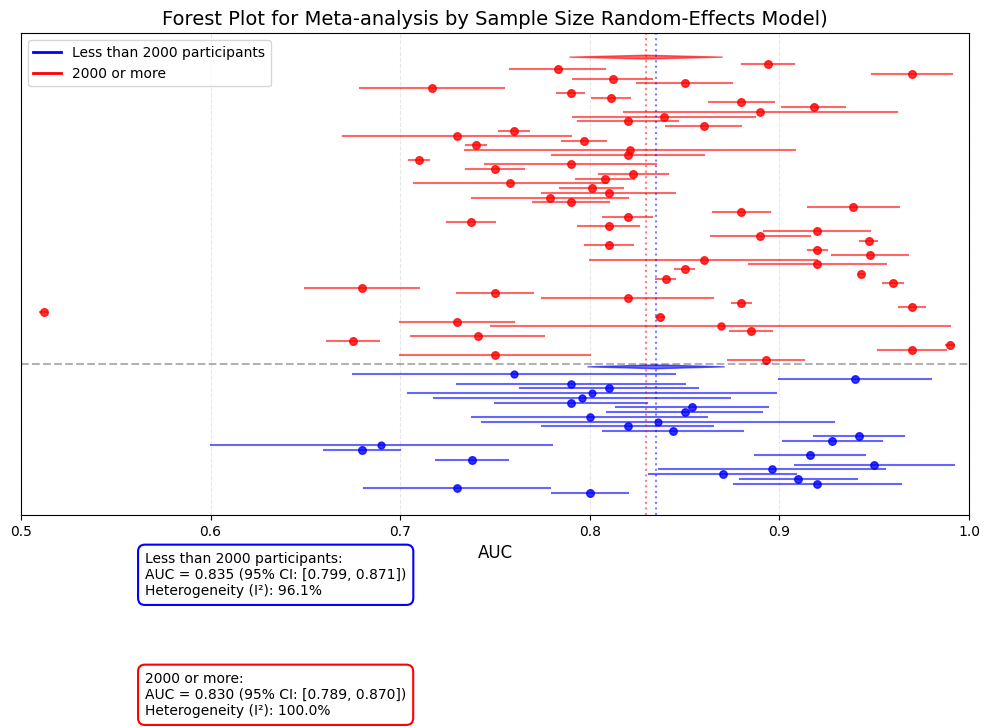


Less than 2000 participants (Random-Effects Model):
AUC = 0.8349 (95% CI: [0.7987, 0.8712])
I² = 96.1%
τ² = 0.008180

2000 or more (Random-Effects Model):
AUC = 0.8297 (95% CI: [0.7893, 0.8701])
I² = 100.0%
τ² = 0.026514


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load Excel data
data = pd.read_excel('/content/drive/MyDrive/Post-doc UFPel/Machine Learning Review & mortality - PDJ/PDJ Review/Meta-analysis/Metacountry.xlsx')

# Function to calculate meta-analysis with random effects model
def random_effects_meta_analysis(aucs, ses):
    # Fixed effects model calculation (necessary to estimate heterogeneity)
    weights_fixed = 1 / ses**2
    weighted_mean_auc_fixed = np.sum(aucs * weights_fixed) / np.sum(weights_fixed)

    # Q statistic calculation (heterogeneity)
    q_total = np.sum(weights_fixed * (aucs - weighted_mean_auc_fixed)**2)
    df_q = len(aucs) - 1

    # I² calculation (percentage of variation due to heterogeneity)
    i_squared = max(0, (q_total - df_q) / q_total * 100) if q_total > 0 else 0

    # tau² calculation (between-study variance) using DerSimonian-Laird method
    c = np.sum(weights_fixed) - (np.sum(weights_fixed**2) / np.sum(weights_fixed))
    tau_squared = max(0, (q_total - df_q) / c)

    # Weights calculation for random effects model
    weights_random = 1 / (ses**2 + tau_squared)

    # Combined estimate calculation for random effects model
    weighted_mean_auc_random = np.sum(aucs * weights_random) / np.sum(weights_random)

    # Standard error for combined estimate
    se_random = np.sqrt(1 / np.sum(weights_random))

    # 95% confidence intervals for combined estimate
    ci_lower = weighted_mean_auc_random - 1.96 * se_random
    ci_upper = weighted_mean_auc_random + 1.96 * se_random

    return weighted_mean_auc_random, ci_lower, ci_upper, i_squared, tau_squared

# Calculating meta-analysis for each subgroup
results = {}
for classification in [1, 2]:
    subgroup_data = data[data['Classification'] == classification]
    aucs = subgroup_data['AUC'].to_numpy()
    ses = subgroup_data['SE'].to_numpy()

    results[classification] = random_effects_meta_analysis(aucs, ses)

# Creating single forest plot
fig, ax = plt.subplots(figsize=(10, 8))

colors = {1: 'blue', 2: 'red'}
labels = {1: 'Less than 2000 participants', 2: '2000 or more'}

# Plotting confidence intervals for each subgroup
for classification in [1, 2]:
    subgroup_data = data[data['Classification'] == classification]
    aucs = subgroup_data['AUC'].to_numpy()
    ses = subgroup_data['SE'].to_numpy()

    ci_upper = aucs + 1.96 * ses
    ci_lower = aucs - 1.96 * ses

    # Calculating weights for point size (for random effects model)
    tau_squared = results[classification][4]
    weights_random = 1 / (ses**2 + tau_squared)
    point_sizes = 30 * weights_random / np.max(weights_random)

    # Adjusting position on y-axis to separate subgroups
    positions = range(len(aucs))
    if classification == 2:
        positions = [pos + len(data[data['Classification'] == 1]) + 2 for pos in positions]

    # Plotting confidence interval lines
    for i, (auc, lower, upper, pos, size) in enumerate(zip(aucs, ci_lower, ci_upper, positions, point_sizes)):
        ax.plot([lower, upper], [pos, pos], '-', color=colors[classification], alpha=0.6)
        ax.plot(auc, pos, 'o', color=colors[classification], alpha=0.8,
                markersize=np.sqrt(size), label=labels[classification] if i == 0 else "")

# Adding weighted mean AUCs from random effects model for each subgroup
for classification in [1, 2]:
    weighted_mean_auc, ci_lower, ci_upper, i_squared, tau_squared = results[classification]

    # Position for subgroup result
    if classification == 1:
        pos = len(data[data['Classification'] == 1]) + 0.5
    else:
        pos = len(data) + 2.5

    # Drawing diamond to represent combined estimate
    diamond_height = 0.4
    diamond_xs = [ci_lower, weighted_mean_auc, ci_upper, weighted_mean_auc, ci_lower]
    diamond_ys = [pos, pos + diamond_height, pos, pos - diamond_height, pos]
    ax.fill(diamond_xs, diamond_ys, color=colors[classification], alpha=0.6)

    # Vertical line for combined estimate
    ax.axvline(weighted_mean_auc, color=colors[classification], linestyle='dotted', alpha=0.5)

# Adding plot details
ax.set_yticks([])  # Removing y-axis ticks
ax.grid(True, axis='x', linestyle='--', alpha=0.3)
ax.set_xlabel('AUC', fontsize=12)
ax.set_title('Forest Plot for Meta-analysis by Sample Size (Random-Effects Model)', fontsize=14)

# Setting x-axis limits
ax.set_xlim(0.5, 1)  # Limiting x-axis from 0.5 to 1

# Adding text box for each subgroup
y_positions = [0.25, 0.1]
for i, classification in enumerate([1, 2]):
    weighted_mean_auc, ci_lower, ci_upper, i_squared, tau_squared = results[classification]
    result_text = f'{labels[classification]}:\nAUC = {weighted_mean_auc:.3f} (95% CI: [{ci_lower:.3f}, {ci_upper:.3f}])\nHeterogeneity (I²): {i_squared:.1f}%'
    plt.figtext(0.15, y_positions[i], result_text, bbox=dict(boxstyle="round,pad=0.5",
                                                           facecolor='white',
                                                           edgecolor=colors[classification],
                                                           lw=1.5),
                horizontalalignment='left')

# Adding custom legend
custom_lines = [plt.Line2D([0], [0], color=colors[1], lw=2),
                plt.Line2D([0], [0], color=colors[2], lw=2)]
ax.legend(custom_lines, [labels[1], labels[2]], loc='upper left')

# Adding visual separators between subgroups
y_sep = len(data[data['Classification'] == 1]) + 1
ax.axhline(y=y_sep, color='black', linestyle='--', alpha=0.3)

# Adjusting layout
plt.tight_layout()
plt.subplots_adjust(bottom=0.35)  # Adjusting to make space for text boxes
plt.show()

# Printing results to console for reference
for classification in [1, 2]:
    weighted_mean_auc, ci_lower, ci_upper, i_squared, tau_squared = results[classification]
    print(f"\n{labels[classification]} (Random-Effects Model):")
    print(f"AUC = {weighted_mean_auc:.4f} (95% CI: [{ci_lower:.4f}, {ci_upper:.4f}])")
    print(f"I² = {i_squared:.1f}%")
    print(f"τ² = {tau_squared:.6f}")

**TRIPOD AI analysis: less than 35 points vs. 35 or more**

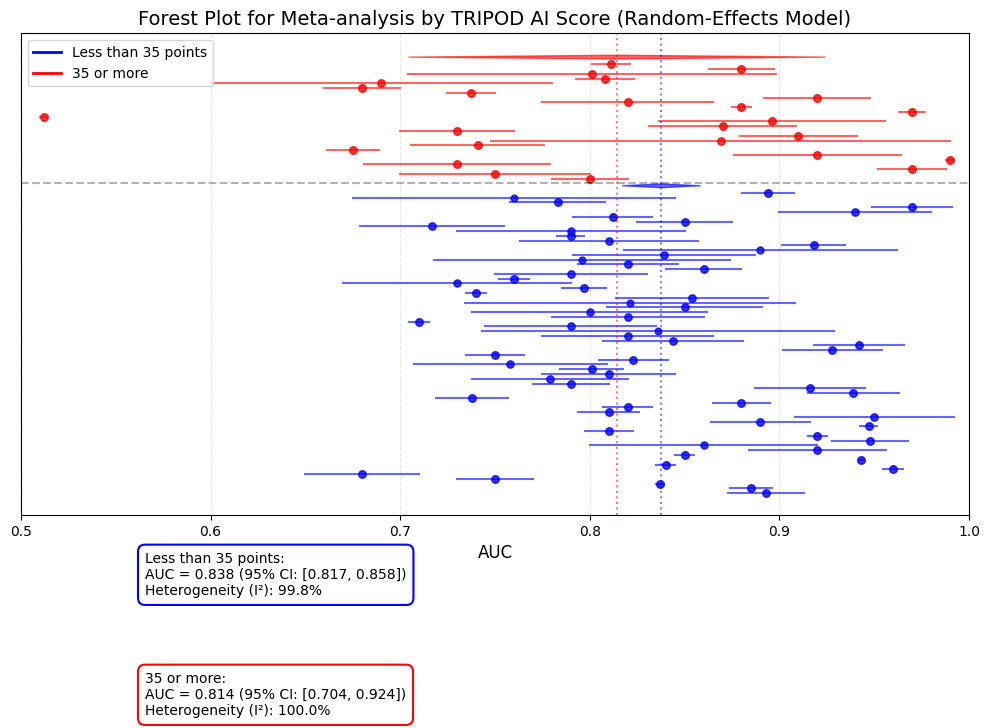


Less than 35 points (Random-Effects Model):
AUC = 0.8377 (95% CI: [0.8170, 0.8584])
I² = 99.8%
τ² = 0.006818

35 or more (Random-Effects Model):
AUC = 0.8144 (95% CI: [0.7045, 0.9244])
I² = 100.0%
τ² = 0.078189


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load Excel data
data = pd.read_excel('/content/drive/MyDrive/Post-doc UFPel/Machine Learning Review & mortality - PDJ/PDJ Review/Meta-analysis/Metatripod.xlsx')

# Function to calculate meta-analysis with random effects model
def random_effects_meta_analysis(aucs, ses):
    # Fixed effects model calculation (necessary to estimate heterogeneity)
    weights_fixed = 1 / ses**2
    weighted_mean_auc_fixed = np.sum(aucs * weights_fixed) / np.sum(weights_fixed)

    # Q statistic calculation (heterogeneity)
    q_total = np.sum(weights_fixed * (aucs - weighted_mean_auc_fixed)**2)
    df_q = len(aucs) - 1

    # I² calculation (percentage of variation due to heterogeneity)
    i_squared = max(0, (q_total - df_q) / q_total * 100) if q_total > 0 else 0

    # tau² calculation (between-study variance) using DerSimonian-Laird method
    c = np.sum(weights_fixed) - (np.sum(weights_fixed**2) / np.sum(weights_fixed))
    tau_squared = max(0, (q_total - df_q) / c)

    # Weights calculation for random effects model
    weights_random = 1 / (ses**2 + tau_squared)

    # Combined estimate calculation for random effects model
    weighted_mean_auc_random = np.sum(aucs * weights_random) / np.sum(weights_random)

    # Standard error for combined estimate
    se_random = np.sqrt(1 / np.sum(weights_random))

    # 95% confidence intervals for combined estimate
    ci_lower = weighted_mean_auc_random - 1.96 * se_random
    ci_upper = weighted_mean_auc_random + 1.96 * se_random

    return weighted_mean_auc_random, ci_lower, ci_upper, i_squared, tau_squared

# Calculating meta-analysis for each subgroup
results = {}
for classification in [1, 2]:
    subgroup_data = data[data['Classification'] == classification]
    aucs = subgroup_data['AUC'].to_numpy()
    ses = subgroup_data['SE'].to_numpy()

    results[classification] = random_effects_meta_analysis(aucs, ses)

# Creating single forest plot
fig, ax = plt.subplots(figsize=(10, 8))

colors = {1: 'blue', 2: 'red'}
labels = {1: 'Less than 35 points', 2: '35 or more'}

# Plotting confidence intervals for each subgroup
for classification in [1, 2]:
    subgroup_data = data[data['Classification'] == classification]
    aucs = subgroup_data['AUC'].to_numpy()
    ses = subgroup_data['SE'].to_numpy()

    ci_upper = aucs + 1.96 * ses
    ci_lower = aucs - 1.96 * ses

    # Calculating weights for point size (for random effects model)
    tau_squared = results[classification][4]
    weights_random = 1 / (ses**2 + tau_squared)
    point_sizes = 30 * weights_random / np.max(weights_random)

    # Adjusting position on y-axis to separate subgroups
    positions = range(len(aucs))
    if classification == 2:
        positions = [pos + len(data[data['Classification'] == 1]) + 2 for pos in positions]

    # Plotting confidence interval lines
    for i, (auc, lower, upper, pos, size) in enumerate(zip(aucs, ci_lower, ci_upper, positions, point_sizes)):
        ax.plot([lower, upper], [pos, pos], '-', color=colors[classification], alpha=0.6)
        ax.plot(auc, pos, 'o', color=colors[classification], alpha=0.8,
                markersize=np.sqrt(size), label=labels[classification] if i == 0 else "")

# Adding weighted mean AUCs from random effects model for each subgroup
for classification in [1, 2]:
    weighted_mean_auc, ci_lower, ci_upper, i_squared, tau_squared = results[classification]

    # Position for subgroup result
    if classification == 1:
        pos = len(data[data['Classification'] == 1]) + 0.5
    else:
        pos = len(data) + 2.5

    # Drawing diamond to represent combined estimate
    diamond_height = 0.4
    diamond_xs = [ci_lower, weighted_mean_auc, ci_upper, weighted_mean_auc, ci_lower]
    diamond_ys = [pos, pos + diamond_height, pos, pos - diamond_height, pos]
    ax.fill(diamond_xs, diamond_ys, color=colors[classification], alpha=0.6)

    # Vertical line for combined estimate
    ax.axvline(weighted_mean_auc, color=colors[classification], linestyle='dotted', alpha=0.5)

# Adding plot details
ax.set_yticks([])  # Removing y-axis ticks
ax.grid(True, axis='x', linestyle='--', alpha=0.3)
ax.set_xlabel('AUC', fontsize=12)
ax.set_title('Forest Plot for Meta-analysis by TRIPOD AI Score (Random-Effects Model)', fontsize=14)

# Setting x-axis limits
ax.set_xlim(0.5, 1)  # Limiting x-axis from 0.5 to 1

# Adding text box for each subgroup
y_positions = [0.25, 0.1]
for i, classification in enumerate([1, 2]):
    weighted_mean_auc, ci_lower, ci_upper, i_squared, tau_squared = results[classification]
    result_text = f'{labels[classification]}:\nAUC = {weighted_mean_auc:.3f} (95% CI: [{ci_lower:.3f}, {ci_upper:.3f}])\nHeterogeneity (I²): {i_squared:.1f}%'
    plt.figtext(0.15, y_positions[i], result_text, bbox=dict(boxstyle="round,pad=0.5",
                                                           facecolor='white',
                                                           edgecolor=colors[classification],
                                                           lw=1.5),
                horizontalalignment='left')

# Adding custom legend
custom_lines = [plt.Line2D([0], [0], color=colors[1], lw=2),
                plt.Line2D([0], [0], color=colors[2], lw=2)]
ax.legend(custom_lines, [labels[1], labels[2]], loc='upper left')

# Adding visual separators between subgroups
y_sep = len(data[data['Classification'] == 1]) + 1
ax.axhline(y=y_sep, color='black', linestyle='--', alpha=0.3)

# Adjusting layout
plt.tight_layout()
plt.subplots_adjust(bottom=0.35)  # Adjusting to make space for text boxes
plt.show()

# Printing results to console for reference
for classification in [1, 2]:
    weighted_mean_auc, ci_lower, ci_upper, i_squared, tau_squared = results[classification]
    print(f"\n{labels[classification]} (Random-Effects Model):")
    print(f"AUC = {weighted_mean_auc:.4f} (95% CI: [{ci_lower:.4f}, {ci_upper:.4f}])")
    print(f"I² = {i_squared:.1f}%")
    print(f"τ² = {tau_squared:.6f}")

**Analysis by Models**

Tree-based and Tree Ensemble Models = 1

Neural Networks = 2

Linear/Statistical Models = 3

Ensemble/Hybrid Models = 4

Other Models = 5

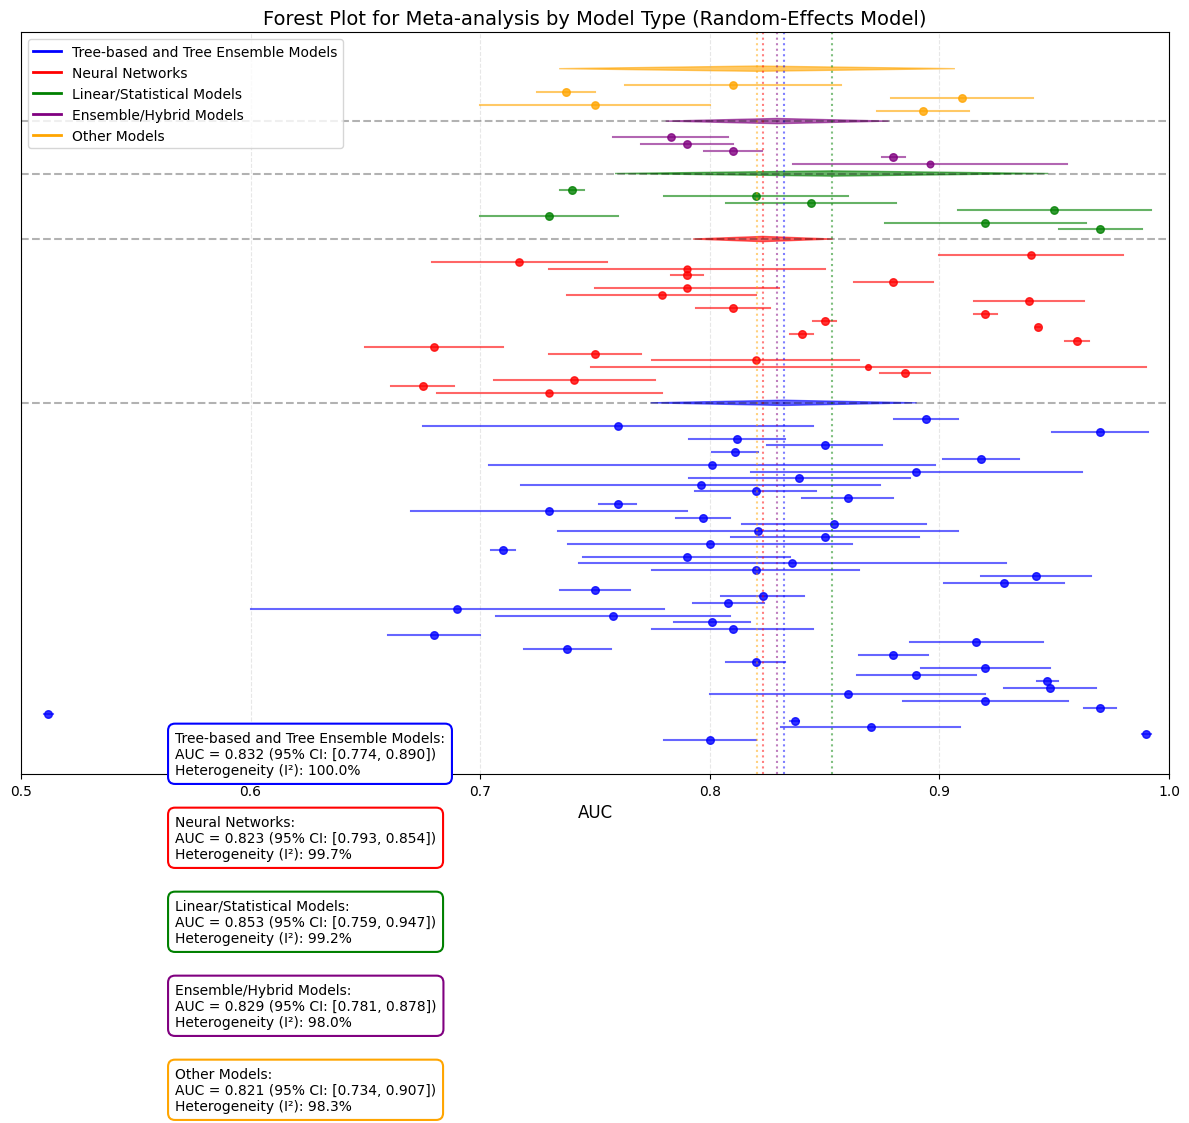

<Figure size 1200x1600 with 0 Axes>


Tree-based and Tree Ensemble Models (Random-Effects Model):
AUC = 0.8322 (95% CI: [0.7743, 0.8901])
I² = 100.0%
τ² = 0.043218

Neural Networks (Random-Effects Model):
AUC = 0.8231 (95% CI: [0.7927, 0.8535])
I² = 99.7%
τ² = 0.004990

Linear/Statistical Models (Random-Effects Model):
AUC = 0.8531 (95% CI: [0.7587, 0.9474])
I² = 99.2%
τ² = 0.015922

Ensemble/Hybrid Models (Random-Effects Model):
AUC = 0.8294 (95% CI: [0.7808, 0.8779])
I² = 98.0%
τ² = 0.002856

Other Models (Random-Effects Model):
AUC = 0.8206 (95% CI: [0.7344, 0.9068])
I² = 98.3%
τ² = 0.009348


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load Excel data
data = pd.read_excel('/content/drive/MyDrive/Post-doc UFPel/Machine Learning Review & mortality - PDJ/PDJ Review/Meta-analysis/Metamodel.xlsx')

# Function to calculate meta-analysis with random effects model
def random_effects_meta_analysis(aucs, ses):
    # Fixed effects model calculation (necessary to estimate heterogeneity)
    weights_fixed = 1 / ses**2
    weighted_mean_auc_fixed = np.sum(aucs * weights_fixed) / np.sum(weights_fixed)

    # Q statistic calculation (heterogeneity)
    q_total = np.sum(weights_fixed * (aucs - weighted_mean_auc_fixed)**2)
    df_q = len(aucs) - 1

    # I² calculation (percentage of variation due to heterogeneity)
    i_squared = max(0, (q_total - df_q) / q_total * 100) if q_total > 0 else 0

    # tau² calculation (between-study variance) using DerSimonian-Laird method
    c = np.sum(weights_fixed) - (np.sum(weights_fixed**2) / np.sum(weights_fixed))
    tau_squared = max(0, (q_total - df_q) / c)

    # Weights calculation for random effects model
    weights_random = 1 / (ses**2 + tau_squared)

    # Combined estimate calculation for random effects model
    weighted_mean_auc_random = np.sum(aucs * weights_random) / np.sum(weights_random)

    # Standard error for combined estimate
    se_random = np.sqrt(1 / np.sum(weights_random))

    # 95% confidence intervals for combined estimate
    ci_lower = weighted_mean_auc_random - 1.96 * se_random
    ci_upper = weighted_mean_auc_random + 1.96 * se_random

    return weighted_mean_auc_random, ci_lower, ci_upper, i_squared, tau_squared

# Calculating meta-analysis for each subgroup
results = {}
classifications = [1, 2, 3, 4, 5]  # 5 classifications
for classification in classifications:
    subgroup_data = data[data['Classification'] == classification]
    if len(subgroup_data) > 0:  # Checking if there is data for this classification
        aucs = subgroup_data['AUC'].to_numpy()
        ses = subgroup_data['SE'].to_numpy()
        results[classification] = random_effects_meta_analysis(aucs, ses)
    else:
        # Handle the case where there are no studies for a classification
        results[classification] = (np.nan, np.nan, np.nan, np.nan, np.nan)

# Creating single forest plot
fig, ax = plt.subplots(figsize=(12, 12))  # Increasing size to accommodate more groups

# Defining colors and labels for each classification
colors = {
    1: 'blue',       # Tree-based and Tree Ensemble Models
    2: 'red',        # Neural Networks
    3: 'green',      # Linear/Statistical Models
    4: 'purple',     # Ensemble/Hybrid Models
    5: 'orange'      # Other Models
}

labels = {
    1: 'Tree-based and Tree Ensemble Models',
    2: 'Neural Networks',
    3: 'Linear/Statistical Models',
    4: 'Ensemble/Hybrid Models',
    5: 'Other Models'
}

# Starting positions for each group
group_start_positions = {}
current_position = 0

for classification in classifications:
    subgroup_data = data[data['Classification'] == classification]
    group_start_positions[classification] = current_position
    current_position += len(subgroup_data) + 3  # Add space between groups

# Plotting confidence intervals for each subgroup
for classification in classifications:
    subgroup_data = data[data['Classification'] == classification]
    if len(subgroup_data) == 0:
        continue  # Skip if there's no data

    aucs = subgroup_data['AUC'].to_numpy()
    ses = subgroup_data['SE'].to_numpy()

    ci_upper = aucs + 1.96 * ses
    ci_lower = aucs - 1.96 * ses

    # Calculating weights for point size (for random effects model)
    tau_squared = results[classification][4]
    if np.isnan(tau_squared):
        point_sizes = np.ones_like(ses) * 30  # Default size if tau² is NaN
    else:
        weights_random = 1 / (ses**2 + tau_squared)
        point_sizes = 30 * weights_random / np.max(weights_random)

    # Adjusting position on y-axis
    start_pos = group_start_positions[classification]
    positions = [start_pos + i for i in range(len(aucs))]

    # Plotting confidence interval lines
    for i, (auc, lower, upper, pos, size) in enumerate(zip(aucs, ci_lower, ci_upper, positions, point_sizes)):
        ax.plot([lower, upper], [pos, pos], '-', color=colors[classification], alpha=0.6)
        ax.plot(auc, pos, 'o', color=colors[classification], alpha=0.8,
                markersize=np.sqrt(size), label=labels[classification] if i == 0 else "")

# Adding weighted mean AUCs from random effects model for each subgroup
for classification in classifications:
    if np.isnan(results[classification][0]):
        continue  # Skip if there are no valid results

    weighted_mean_auc, ci_lower, ci_upper, i_squared, tau_squared = results[classification]

    # Position for subgroup result
    group_end = group_start_positions[classification] + len(data[data['Classification'] == classification])
    pos = group_end + 1.5

    # Drawing diamond to represent combined estimate
    diamond_height = 0.4
    diamond_xs = [ci_lower, weighted_mean_auc, ci_upper, weighted_mean_auc, ci_lower]
    diamond_ys = [pos, pos + diamond_height, pos, pos - diamond_height, pos]
    ax.fill(diamond_xs, diamond_ys, color=colors[classification], alpha=0.6)

    # Vertical line for combined estimate
    ax.axvline(weighted_mean_auc, color=colors[classification], linestyle='dotted', alpha=0.5)

# Adding plot details
ax.set_yticks([])  # Removing y-axis ticks
ax.grid(True, axis='x', linestyle='--', alpha=0.3)
ax.set_xlabel('AUC', fontsize=12)
ax.set_title('Forest Plot for Meta-analysis by Model Type (Random-Effects Model)', fontsize=14)

# Setting x-axis limits
ax.set_xlim(0.5, 1)  # Limiting x-axis from 0.5 to 1

# Adding text box for each subgroup
y_positions = [0.35, 0.28, 0.21, 0.14, 0.07]  # Vertical positions adjusted for 5 groups
for i, classification in enumerate(classifications):
    if np.isnan(results[classification][0]):
        continue  # Skip if there are no valid results

    weighted_mean_auc, ci_lower, ci_upper, i_squared, tau_squared = results[classification]
    result_text = f'{labels[classification]}:\nAUC = {weighted_mean_auc:.3f} (95% CI: [{ci_lower:.3f}, {ci_upper:.3f}])\nHeterogeneity (I²): {i_squared:.1f}%'
    plt.figtext(0.15, y_positions[i], result_text, bbox=dict(boxstyle="round,pad=0.5",
                                                           facecolor='white',
                                                           edgecolor=colors[classification],
                                                           lw=1.5),
                horizontalalignment='left')

# Adding custom legend
custom_lines = [plt.Line2D([0], [0], color=colors[c], lw=2) for c in classifications]
ax.legend(custom_lines, [labels[c] for c in classifications], loc='upper left')

# Adding visual separators between subgroups
for classification in classifications[:-1]:  # All except the last one
    if classification in group_start_positions:
        next_class = classification + 1
        while next_class <= 5 and next_class not in group_start_positions:
            next_class += 1

        if next_class in group_start_positions:
            y_sep = (group_start_positions[classification] + len(data[data['Classification'] == classification]) +
                     group_start_positions[next_class]) / 2
            ax.axhline(y=y_sep, color='black', linestyle='--', alpha=0.3)

# Adjusting layout and plot size to accommodate all groups
plt.tight_layout()
plt.subplots_adjust(bottom=0.35)  # Adjusting to make space for text boxes
plt.figure(figsize=(12, 6 + 2 * len(classifications)))  # Adjusting size according to number of groups
plt.show()

# Printing results to console for reference
for classification in classifications:
    if np.isnan(results[classification][0]):
        print(f"\n{labels[classification]}: Insufficient data for meta-analysis")
        continue

    weighted_mean_auc, ci_lower, ci_upper, i_squared, tau_squared = results[classification]
    print(f"\n{labels[classification]} (Random-Effects Model):")
    print(f"AUC = {weighted_mean_auc:.4f} (95% CI: [{ci_lower:.4f}, {ci_upper:.4f}])")
    print(f"I² = {i_squared:.1f}%")
    print(f"τ² = {tau_squared:.6f}")